<a href="https://colab.research.google.com/github/RayyanShajahan/My-codes/blob/main/deep_learning_day4_pt3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#face emotion identification using deep learning(CNN)

In [9]:
import tensorflow as tf
import os
import zipfile

# Define image dimensions and batch size
img_height, img_width = 128, 128  # You can adjust these values
batch_size = 32

# --- Start of updated dataset_path determination logic ---
final_dataset_path = None
initial_extracted_dir = 'emt'
zip_file_location = '/content/emt.zip'
nested_dir_path = os.path.join(initial_extracted_dir, initial_extracted_dir)

# 1. Ensure the top-level extraction directory exists and contains the zipped content
if not os.path.exists(initial_extracted_dir):
    print(f"'{initial_extracted_dir}' not found. Attempting to extract '{zip_file_location}'.")
    if os.path.exists(zip_file_location):
        try:
            os.makedirs(initial_extracted_dir, exist_ok=True)
            with zipfile.ZipFile(zip_file_location, 'r') as zip_ref:
                zip_ref.extractall(initial_extracted_dir)
            print(f"Successfully extracted '{zip_file_location}' to '{initial_extracted_dir}'.")
        except zipfile.BadZipFile:
            print(f"Error: '{zip_file_location}' is not a valid zip file.")
        except Exception as e:
            print(f"An error occurred during extraction: {e}")
    else:
        print(f"Error: '{zip_file_location}' not found. Please upload the zip file.")
elif not os.listdir(initial_extracted_dir): # Check if directory is empty
    print(f"'{initial_extracted_dir}' exists but is empty. Re-attempting extraction.")
    if os.path.exists(zip_file_location):
        try:
            with zipfile.ZipFile(zip_file_location, 'r') as zip_ref:
                zip_ref.extractall(initial_extracted_dir)
            print(f"Successfully re-extracted '{zip_file_location}' to '{initial_extracted_dir}'.")
        except Exception as e:
            print(f"An error occurred during re-extraction: {e}")
    else:
        print(f"Error: '{zip_file_location}' not found for re-extraction.")


# 2. Check for the known nested structure (emt/emt) and set final_dataset_path
if os.path.exists(nested_dir_path) and os.listdir(nested_dir_path): # Also check if nested dir is not empty
    final_dataset_path = nested_dir_path
    print(f"Detected nested directory structure. Setting dataset_path to: {final_dataset_path}")
elif os.path.exists(initial_extracted_dir) and os.listdir(initial_extracted_dir): # Fallback if no nested, but top-level has content
    final_dataset_path = initial_extracted_dir
    print(f"Using top-level extracted directory. Setting dataset_path to: {final_dataset_path}")
    print("Warning: If 'tf.keras.utils.image_dataset_from_directory' reports 1 class, the structure might still be nested differently than expected.")
else:
    print(f"Error: No valid dataset directory found after extraction. Checked '{initial_extracted_dir}' and '{nested_dir_path}'.")

dataset_path = final_dataset_path # Assign to the variable used later in the cell
# --- End of updated dataset_path determination logic ---


# Now, proceed only if dataset_path is successfully defined
if dataset_path:
    # Create training and validation datasets
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    # Get class names
    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"Found {num_classes} classes: {class_names}")

    # Configure the dataset for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    print("Data preparation complete. Training and validation datasets created.")
else:
    print("Cannot proceed with data preparation: dataset_path is not defined correctly. Please check previous output for errors.")

Detected nested directory structure. Setting dataset_path to: emt/emt
Found 200 files belonging to 4 classes.
Using 160 files for training.
Found 200 files belonging to 4 classes.
Using 40 files for validation.
Found 4 classes: ['angry', 'happy', 'sad', 'suprise']
Data preparation complete. Training and validation datasets created.


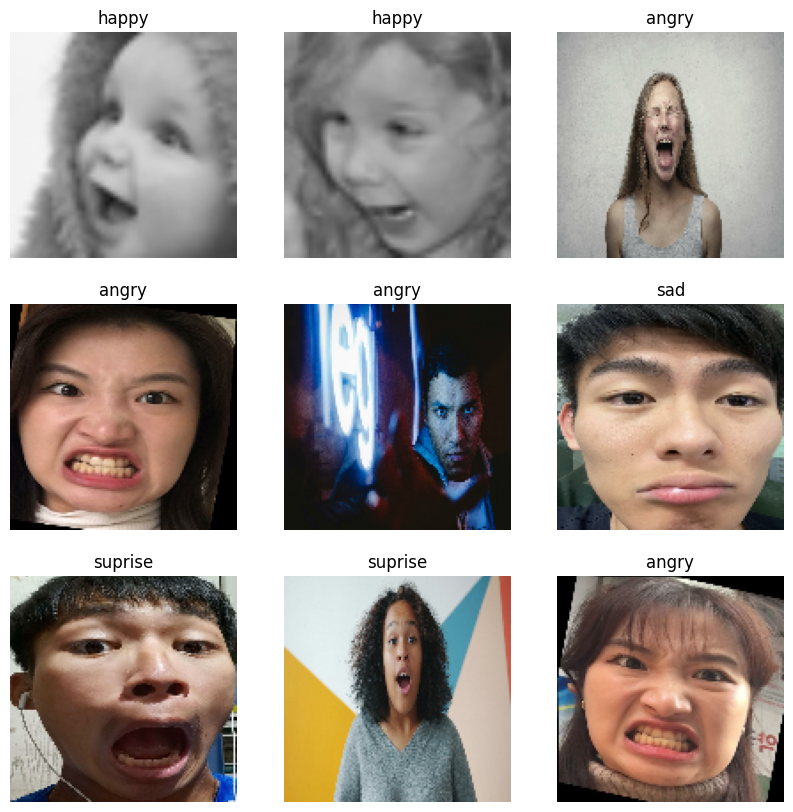

In [10]:
import matplotlib.pyplot as plt

if 'train_ds' in locals():
    plt.figure(figsize=(10, 10))
    for images, labels in train_ds.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.show()
else:
    print("Training dataset not found. Please ensure the previous cell ran successfully.")

In [12]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Normalize pixel values
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [14]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3313 - loss: 1.4077 - val_accuracy: 0.3750 - val_loss: 1.4645
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 980ms/step - accuracy: 0.4250 - loss: 1.3131 - val_accuracy: 0.5500 - val_loss: 1.2225
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 978ms/step - accuracy: 0.6000 - loss: 1.1221 - val_accuracy: 0.6500 - val_loss: 1.0771
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6687 - loss: 0.8904 - val_accuracy: 0.6250 - val_loss: 1.2735
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6875 - loss: 0.7684 - val_accuracy: 0.7000 - val_loss: 1.2289
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7688 - loss: 0.6738 - val_accuracy: 0.6500 - val_loss: 1.0379
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 994ms/step - accuracy: 0.8062 - loss: 0.6047 - val_accuracy: 0.6750 - val_loss: 1.0438
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8125 - loss: 0.4698 - val_accuracy: 0.6750 - val_loss: 1.1253
Epoch 

In [17]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7000 - loss: 1.2759
Validation Loss: 1.2759
Validation Accuracy: 0.7000


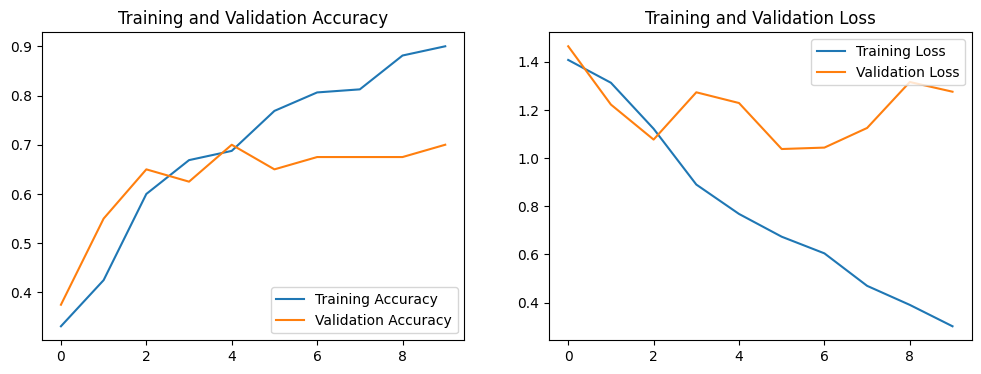

In [18]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Displaying 5 sample images from the validation set with true and predicted emotions:


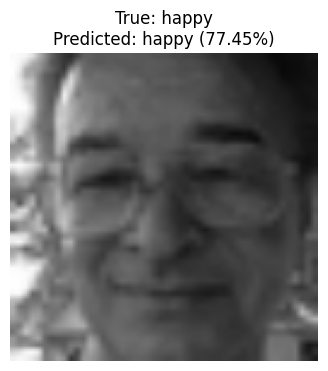

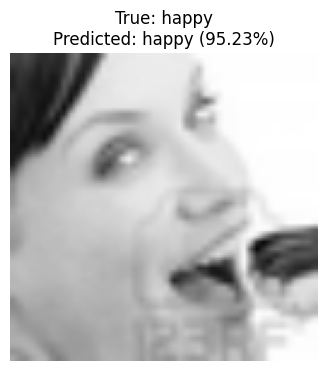

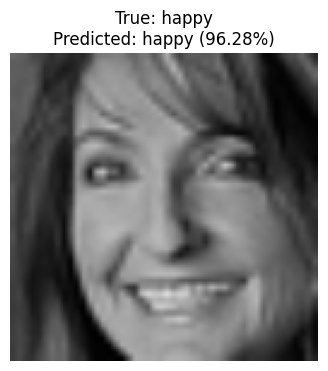

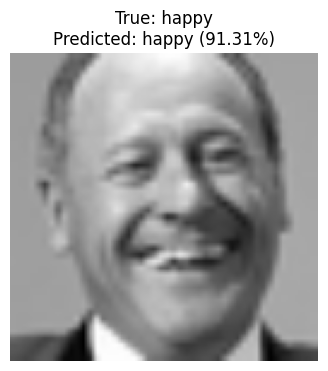

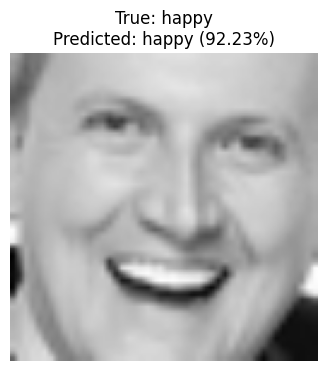

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Function to display image with true and predicted labels
def display_prediction(img_tensor, true_label_index, predicted_probabilities):
    plt.figure(figsize=(4, 4))
    plt.imshow(img_tensor.numpy().astype("uint8"))

    true_emotion = class_names[true_label_index]
    predicted_class_index = np.argmax(predicted_probabilities[0])
    predicted_emotion = class_names[predicted_class_index]
    confidence = np.max(predicted_probabilities[0])

    plt.title(f"True: {true_emotion}\nPredicted: {predicted_emotion} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

print("Displaying 5 sample images from the validation set with true and predicted emotions:")

displayed_count = 0
for images, labels in val_ds.unbatch(): # Unbatch to process individual images
    if displayed_count >= 5:
        break

    # Expand dimensions for prediction (model expects a batch)
    img_for_prediction = np.expand_dims(images.numpy(), axis=0)

    # Predictions are already normalized by the Rescaling layer in the model
    predictions = model.predict(img_for_prediction, verbose=0) # verbose=0 to suppress progress bar

    display_prediction(images, labels.numpy(), predictions)
    displayed_count += 1
